<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/CT_Liver_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting up for Liver Segmentation

This notebook will guide you through the process of setting up a deep learning pipeline for liver segmentation in CT scans. We'll start with essential library imports and data loading.

In [3]:
# Install necessary libraries. Uncomment and run if you don't have them.
# !pip install monai
!pip install SimpleITK
# !pip install numpy pandas matplotlib scikit-image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

# Deep learning frameworks (choose one, or both)
# import torch
# import tensorflow as tf

# from monai.transforms import (
#     Compose,
#     LoadImaged,
#     AddChanneld,
#     ScaleIntensityRanged,
#     CropForegroundd,
#     Orientationd,
#     Spacingd,
# )
# from monai.data import decollate_batch, DataLoader, Dataset, CacheDataset
# from monai.utils import first
# from monai.networks.nets import UNet
# from monai.inferers import sliding_window_inference
# from monai.metrics import DiceMetric
# from monai.losses import DiceLoss

print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 18.4 MB/s eta 0:00:00
Libraries imported successfully.


In [4]:
# Install MONAI. This might take a minute.
!pip install monai-weekly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.7 MB/s eta 0:00:00


Now that MONAI is installed, let's use its `DownloadAndExtract` utility to fetch a sample dataset. We'll use the 'Task09_Spleen' dataset from the Medical Segmentation Decathlon, as it's a good example for 3D medical image segmentation and is relatively small for quick download. You can later adapt this to other datasets like liver (Task03_Liver) once you're comfortable with the workflow.

In [6]:
import os
from monai.transforms import LoadImaged, Orientationd, Spacingd, ScaleIntensityRanged, CropForegroundd, EnsureChannelFirstd
from monai.data import CacheDataset, DataLoader
from monai.utils import first
from monai.apps import DecathlonDataset

# Set up data directory
data_dir = './data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Download and extract the Task09_Spleen dataset
# This will download the dataset to data_dir and organize it.
# Setting 'val_frac' to 0 ensures we get all data for now, not just training split
# 'transform' is set to a simple LoadImaged to just load the images after download.

train_ds = DecathlonDataset(
    root_dir=data_dir,
    task="Task09_Spleen",
    section="training",
    download=True,  # Set to True to download if not present
    cache_rate=0.0,  # No caching for initial download and check
    num_workers=0,
    transform=LoadImaged(keys=["image", "label"])
)

# Access a single item to confirm download and loading
sample_data = train_ds[0]

print(f"Successfully downloaded and loaded a sample from Task09_Spleen.")
print(f"Sample image metadata keys: {sample_data['image'].meta.keys()}")
print(f"Sample image shape: {sample_data['image'].shape}")
print(f"Sample label shape: {sample_data['label'].shape}")

Task09_Spleen.tar: 1.50GB [00:22, 72.6MB/s]                            

2026-04-26 16:39:45,908 - INFO - Downloaded: data/Task09_Spleen.tar


2026-04-26 16:39:49,362 - INFO - Verified 'Task09_Spleen.tar', md5: 410d4a301da4e5b2f6f86ec3ddba524e.
2026-04-26 16:39:49,363 - INFO - Writing into directory: data.
Successfully downloaded and loaded a sample from Task09_Spleen.
Sample image metadata keys: dict_keys(['sizeof_hdr', 'extents', 'session_error', 'dim_info', 'dim', 'intent_p1', 'intent_p2', 'intent_p3', 'intent_code', 'datatype', 'bitpix', 'slice_start', 'pixdim', 'vox_offset', 'scl_slope', 'scl_inter', 'slice_end', 'slice_code', 'xyzt_units', 'cal_max', 'cal_min', 'slice_duration', 'toffset', 'glmax', 'glmin', 'qform_code', 'sform_code', 'quatern_b', 'quatern_c', 'quatern_d', 'qoffset_x', 'qoffset_y', 'qoffset_z', 'srow_x', 'srow_y', 'srow_z', original_pixdim, affine, original_affine, 'as_closest_canonical', spatial_shape, space, original_channel_dim, 'filename_or_obj'])
Sample image shape: torch.Size([512, 512, 55])
Sample label shape: torch.Size([512, 512, 55])


### Visualizing a Sample Image and Mask

Now that we have downloaded a sample image and its label, let's visualize a slice to understand the data better.

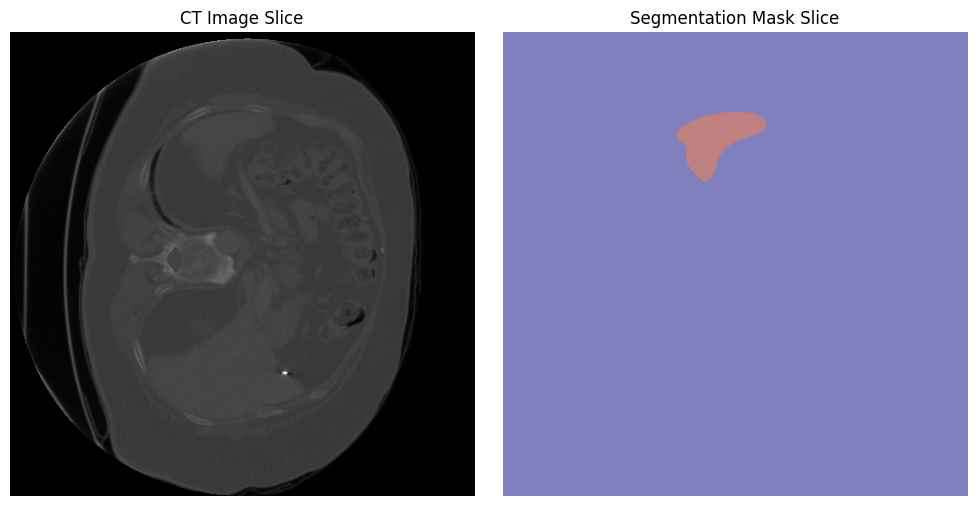

In [7]:
import matplotlib.pyplot as plt

# Get the image and label from the sample_data
image = sample_data['image']
label = sample_data['label']

# Choose a slice to visualize (e.g., the middle slice along the last dimension)
slice_idx = image.shape[-1] // 2

# Extract 2D slices
image_slice = image[:, :, slice_idx]
label_slice = label[:, :, slice_idx]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("CT Image Slice")
plt.imshow(image_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Segmentation Mask Slice")
plt.imshow(label_slice, cmap="jet", alpha=0.5) # Use alpha to see through if needed
plt.axis("off")

plt.tight_layout()
plt.show()


### Define Data Transformations

Before feeding the data to a deep learning model, it's crucial to preprocess it consistently. MONAI provides a powerful `Compose` transform to chain multiple transformations together. For medical imaging, common steps include:

1.  **`LoadImaged`**: Already used, loads Nifti images from the specified keys.
2.  **`EnsureChannelFirstd`**: Adds a channel dimension if not present (e.g., (H, W, D) -> (1, H, W, D)). This is often required by deep learning frameworks.
3.  **`Spacingd`**: Resamples the image to a target voxel spacing, which is important for consistency across different scans.
4.  **`Orientationd`**: Reorients the image to a standard orientation (e.g., RAS: Right-Anterior-Superior), which helps in standardizing coordinate systems.
5.  **`ScaleIntensityRanged`**: Scales the intensity values of the image to a desired range (e.g., 0-1 or -1-1). This is crucial for neural network training.
6.  **`CropForegroundd`**: Crops the image to the foreground region (e.g., removing empty space around the organ), reducing computational load and focusing on relevant areas.
7.  **`ToTensord`**: Converts NumPy arrays or PyTorch Tensors to PyTorch Tensors.

In [ ]:
import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    ScaleIntensityRanged,
    CropForegroundd,
    Orientationd,
    Spacingd,
    EnsureChannelFirstd, # Ensure this is imported
    ToTensord
)
from monai.data import decollate_batch, DataLoader, Dataset, CacheDataset
from monai.utils import first


# Define the paths for images and labels from the downloaded dataset
# The DecathlonDataset already handles this, but for custom datasets, you would list them like this:
# train_images = sorted(glob(os.path.join(data_dir, 'Task09_Spleen', 'imagesTr', '*.nii.gz')))
# train_labels = sorted(glob(os.path.join(data_dir, 'Task09_Spleen', 'labelsTr', '*.nii.gz')))

# Assuming a simple dictionary structure for the dataset items
# The DecathlonDataset already produces this format, so we can directly apply transforms

# Define the transformations for training
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164,
                             b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image", "label"], source_key="image", k_divisible=(16, 16, 16)),
        ToTensord(keys=["image", "label"]),
    ]
)

# For simplicity, we'll reuse the DecathlonDataset and apply the new transforms.
# In a real scenario, you'd split into train/validation datasets.

# Re-initialize DecathlonDataset with the full transform pipeline
train_ds = DecathlonDataset(
    root_dir=data_dir,
    task="Task03_Liver", # Changed from Task09_Spleen to Task03_Liver
    section="training",
    download=True, # Will not re-download if already present
    cache_rate=0.1, # Cache a small portion for speed during development
    num_workers=0,  # Set to a higher number for faster data loading in a production environment
    transform=train_transforms
)

# Create a DataLoader for the training set
train_loader = DataLoader(
    train_ds, batch_size=1, shuffle=True, num_workers=0)


print("Data transformations defined and applied to the training dataset.")

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Task03_Liver.tar: 26.9GB [16:36, 29.0MB/s]                            

2026-04-26 17:19:10,418 - INFO - Downloaded: data/Task03_Liver.tar


Transformed image shape: torch.Size([1, 1, 240, 160, 128])
Transformed label shape: torch.Size([1, 1, 240, 160, 128])
Image data type: torch.float32
Label data type: torch.float32


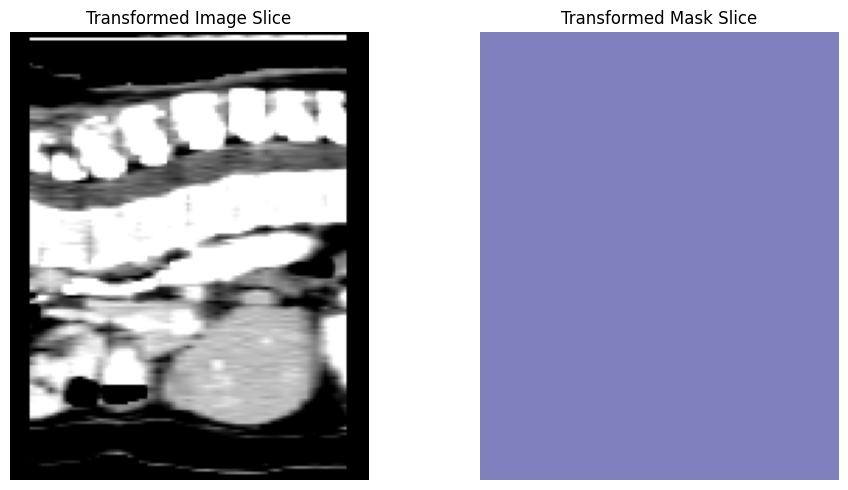

In [12]:
# Fetch one batch of data to check the output of transformations

data_example = first(train_loader)
image, label = data_example["image"], data_example["label"]

print(f"Transformed image shape: {image.shape}")
print(f"Transformed label shape: {label.shape}")
print(f"Image data type: {image.dtype}")
print(f"Label data type: {label.dtype}")

# Visualize a slice of the transformed data
plt.figure(figsize=(10, 5))

# Image is now (Batch, Channel, Depth, Height, Width)
# Remove batch and channel dimensions to get a 3D volume (Depth, Height, Width)
image_volume = image[0, 0]
label_volume = label[0, 0]

# Choose a slice to visualize (e.g., the middle slice along the Depth dimension)
slice_idx = image_volume.shape[0] // 2

# Extract 2D slices
img_slice = image_volume[slice_idx, :, :]
label_slice = label_volume[slice_idx, :, :]

plt.subplot(1, 2, 1)
plt.title("Transformed Image Slice")
plt.imshow(img_slice.cpu().numpy(), cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Transformed Mask Slice")
plt.imshow(label_slice.cpu().numpy(), cmap="jet", alpha=0.5)
plt.axis("off")

plt.tight_layout()
plt.show()

Min value of label_slice: 0.0
Max value of label_slice: 0.0
Unique values in label_slice: tensor([0.])


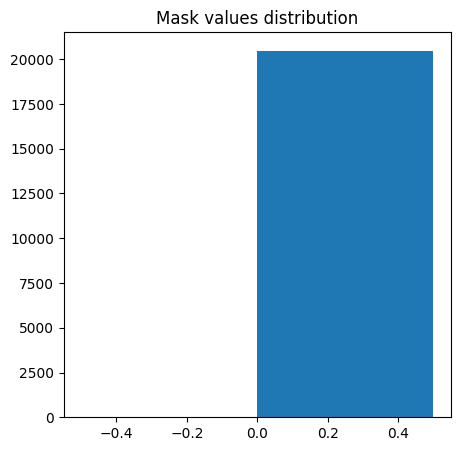

In [13]:
# Inspect the label_slice values
print(f"Min value of label_slice: {label_slice.min().item()}")
print(f"Max value of label_slice: {label_slice.max().item()}")
print(f"Unique values in label_slice: {torch.unique(label_slice)}")

# If the issue is due to a very small range, try normalizing or casting to int
# For binary masks (0 or 1), a simple binary colormap might be better.
plt.figure(figsize=(5, 5))
plt.title("Mask values distribution")
plt.hist(label_slice.cpu().numpy().flatten(), bins=2)
plt.show()

# Re-visualize with a binary colormap if the values are 0 and 1
if label_slice.min().item() == 0 and label_slice.max().item() == 1:
    plt.figure(figsize=(5, 5))
    plt.title("Segmentation Mask Slice (Binary Colormap)")
    plt.imshow(label_slice.cpu().numpy(), cmap="Greys_r") # Greys_r for 0=white, 1=black
    plt.axis("off")
    plt.show()

Total non-zero voxels in label_volume: 17268
Non-zero voxels found in label volume. Let's find a slice with content.
Found a non-empty slice at index: 42


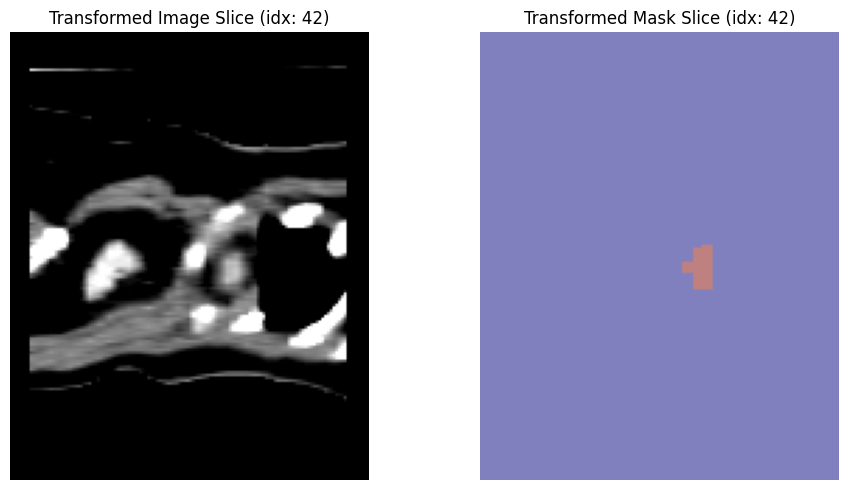

In [14]:
# Check if the entire label volume is empty
non_zero_voxels = torch.sum(label_volume > 0).item()
print(f"Total non-zero voxels in label_volume: {non_zero_voxels}")

if non_zero_voxels == 0:
    print("Warning: The entire label volume is empty (contains no spleen segmentation). This could be due to aggressive cropping, or the chosen sample might not contain the spleen after transformations.")
else:
    print("Non-zero voxels found in label volume. Let's find a slice with content.")
    # Find the first slice that contains foreground
    for i in range(label_volume.shape[0]):
        if torch.sum(label_volume[i, :, :] > 0).item() > 0:
            print(f"Found a non-empty slice at index: {i}")
            slice_idx = i
            break
    else:
        print("Could not find any non-empty slice despite non-zero voxels. This is unexpected.")

    # Re-visualize the found non-empty slice
    img_slice = image_volume[slice_idx, :, :]
    label_slice = label_volume[slice_idx, :, :]

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Transformed Image Slice (idx: {slice_idx})")
    plt.imshow(img_slice.cpu().numpy(), cmap="gray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Transformed Mask Slice (idx: {slice_idx})")
    plt.imshow(label_slice.cpu().numpy(), cmap="jet", alpha=0.5) # Use alpha to see through if needed
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Define U-Net Model

For 3D medical image segmentation, U-Net is a widely used and highly effective architecture. MONAI provides a convenient implementation of U-Net. We'll define a 3D U-Net with appropriate input and output channels, feature map sizes, and activation functions. Given that we are segmenting a single organ (spleen), we will use 1 output channel.

In [15]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm

# Define device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define U-Net model
model = UNet(
    spatial_dims=3,             # 3D image data
    in_channels=1,              # Input image has 1 channel (grayscale CT)
    out_channels=2,             # 2 classes: background and spleen (or liver for future tasks)
    channels=(16, 32, 64, 128, 256), # Number of feature maps at each level
    strides=(2, 2, 2, 2),       # Strides for downsampling
    num_res_units=2,            # Number of residual units at each level
    norm=Norm.BATCH,            # Batch normalization
).to(device)

print("U-Net model defined and moved to device:", device)

U-Net model defined and moved to device: cuda:0
